# Image Super-Resolution with PyTorch: A Beginner Tutorial

In this guide, we will walk you through building, training, and evaluating a convolutional neural network (CNN) designed to enhance the resolution of images. Super-resolution is a process of reconstructing a high-resolution image from a low-resolution input, and it has many practical applications - from improving old photographs to enhancing medical images.

**What this tutorial covers:**
- **Dataset Preparation:** Learn how to download, inspect and explore a super-resolution dataset. We'll cover how to load images, extract useful statistics, and visualize a few examples to get acquainted with your data.
- **Image Preprocessing and Patch Generation:** We'll introduce helper functions to load images, convert between color spaces (RGB and YCbCr), simulate low-resolution images via downscaling, and extract patches from images for training.
- **Custom DataLoader:** Discover how to create a custom PyTorch `Dataset` and `DataLoader` that automatically prepares low- and high-resolution image pairs (or patches) to feed into the model during training and validation.
- **Model Definitions:** We'll build a simple yet effective CNN model inspired by early super-resolution networks. The model architecture uses a few convolutional layers and ReLU activations to map low-resolution images to their high-resolution counterparts.
- **Training Routine:** A complete training loop will be provided, complete with checkpointing, loss monitoring, and early stopping. We'll explain each step of the process, from forward propagation to evaluation metrich like Peak Signal-to-Noise Ratio (PSNR).
- **Evaluation and Visualization:** Finally, you'll learn how to evaluate your trained model on unseen data. The tutorial includes code for computing image quality metrics (PSNR and Structural Similarity Index, SSIM) and visualizing the results to compare the low-resolution, predicted, and original high-resolution images.

Throughout the tutorial, each code block is paired with detailed explanations to help you understand both the "how" and the "why" behind each step. By the end of this tutorial, you'll have a solid foundation in building and deploying super-resolution models using PyTorch, as well as ideas for how to extend and improve upon the baseline model.

## Downloading the Dataset

In this step, we begin by obtaining the data needed to train and evaluate our super-resolution model. Having access to a high-quality dataset is essential because the performance of your model is directly influenced by the quality and variety of the training images. For our tutorial, we use a curated super-resolution dataset available on **Kaggle**. This particular datasets - identified by `"ll01dm/set-5-14-super-resolution-dataset"` and `"ll01dm/t91-image-dataset"` -  include images that are commonly used in super-resolution research, providing a good balance between diversity and complexity.

By downloading this dataset, you'll be able to:
- **Learn from Established Benchmarks:** The datasets are widely referenced in the super-resolution community, which means you'll be working with data that is well-understood and comparable to other research efforts.
- **Facilitate Training and Validation:** The datasets contain high-resolution images that will be downscaled, which is critical for training the model to learn the mapping between low-resolution and high-resolution images.
- **Ensure Reproducibility:** Using a publicly available dataset ensures that others can reproduce your results and compare improvements over established baselines.

The code below uses the `kagglehub` package to download the dataset and prints out the local path where the dataset is stored. This is a crucial first step, setting the stage for all subsequent data processing and model training.

In [ ]:
import kagglehub

# Download latest version
path_5_14 = kagglehub.dataset_download("ll01dm/set-5-14-super-resolution-dataset")
path_t91 = kagglehub.dataset_download("ll01dm/t91-image-dataset")
#
print("Path to dataset set-5 and set-14 files:", path_5_14)
print("Path to dataset t91 files:", path_t91)

```{admonition} Note
:class: important
Move the datasets to the desired folder. Remember their paths and in the code change the path accordingly!
```

## Importing Libraries and Setting Up the Environment

Here, we import all the libraries necessary for our super-resolution tutorial. These libraries provide us with tools for a variety of tasks:
- **Visualization:** We use `matplotlib` (along with its `patches` and `pyplot` submodules) to plot the images and results.
- **Numerical Operations:** `numpy` is essential for handling numerical data and performing array operations.
- **Image Handling:** The `PIL` library is used to load and process images, while `cv2` (OpenCV) helps with color space conversions.
- **Deep Learning:** `torch`, along with its submodules (`torch.nn`, `torchvision`, and `torchinfo`), forms the backbone of our neural network implementation and training routines.
- **Metrics and Utilities:** `skimage.metrics` offers functions like SSIM for image quality assessment.

Additionally, we set up the notebook environment with the `%load_ext autoreload` magic commands to ensure that any changes in the modules are automatically reloaded. This is particularly useful during iterative development. Finally, we configure a default canvas for all our plots by setting `matplotlib.rcParams['figure.figsize']`.

In [1]:
import matplotlib
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import skimage.metrics
import torch
import torchinfo
import cv2
from matplotlib.patches import Rectangle
from skimage.metrics import structural_similarity as ssim_metric

%load_ext autoreload
%autoreload 2
 
# Set a default canvas for plots
matplotlib.rcParams['figure.figsize'] = [12, 8]

```{admonition} Note
:class: important
**Make sure the dataset is downloaded and all the modules are installed.**

One option is to download the modules straight to you python installation. The other, neater, option is to create a virtual environment for your project, and keep the project modules separate from the main installation.

`pip3 install matplotlib numpy scikit-image opencv-python`

NOTE:
For the PyTorch version check their [website](https://pytorch.org/get-started/locally/) for latest stable version and follow their instructions for download.

My case:
`pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124`
```

## Exploring the T91 Dataset 

Here we explore the T91 dataset - a popular benchmark in super-resolution research. We start by specifying the local path, where the dataset is stored, and then we compile a list of all image file paths within that directory. By opening each image with PIL, we extract its dimensions (width and height) to compute key statistics such as number of images, the range of image sizes, and the average dimensions. The statistical overview helps us understand the scale and variability of our dataset before we dive into more complex processing. Finally, we randomly select and display five images, giving us a visual preview that ensures the dataset is loaded correctly and familiarizes us with its content.

Number of images:          91
Interval of image width:   [78, 508]
Interval of image height:  [78, 387]
Average image width:       264.12 +- 96.50
Average image height:      203.58 +- 69.05


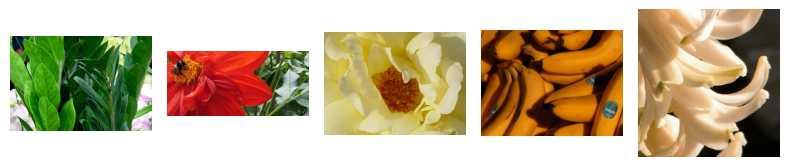

In [2]:
# Set path to the T91 dataset
path = "C:\\Users\\grega\\faks\\mag3\\nsso\\obdelava_slik_s_pytorch\\data\\image_upscale\\T91"

# List all image files in the T91 dataset
img_path_list = [os.path.join(path, name) for name in os.listdir(path)]

# Load all images in the T91 dataset and store their dimensions
widths = []
heights = []

for img_path in img_path_list:
    with PIL.Image.open(img_path) as img:
        width, height = img.size
        widths.append(width)
        heights.append(height)

# Print dataset statistics
print(f"Number of images:          {len(img_path_list)}")
print(f"Interval of image width:   [{np.min(widths)}, {np.max(widths)}]") # [min, max]
print(f"Interval of image height:  [{np.min(heights)}, {np.max(heights)}]") # [min, max]
print(f"Average image width:       {np.mean(widths) :.2f} +- {np.std(widths) :.2f}")
print(f"Average image height:      {np.mean(heights) :.2f} +- {np.std(heights) :.2f}")

# Display 5 random images from the T91 dataset
indices = np.random.default_rng().choice(len(img_path_list), 5, replace=False)

_, axes = plt.subplots(1, 5, figsize=(8, 3), squeeze=False)
for c in range(axes.shape[1]):
    img_path = img_path_list[indices[c]]
    with PIL.Image.open(img_path) as img:
        axes[0, c].imshow(img)
        axes[0, c].axis("off")
            
plt.tight_layout()
plt.show()

## Helper functions for Image Processing

To avoid writing too much redundant code, it is common practice, to wrap repeating code into helper functions, which are then only called into our code when needed. Here we define these functions, which help streamline various image processing tasks needed throughout the tutorial. These functions handle everything from loading and converting images to simulating low-resolution inputs and evaluating image quality. Here is what each function does:
- `load_img_to_tensor`: This function loads an image from a given file path using the PIL library. It converts the image to RGB (ensuring consistency even if the source image isn't in RGB), transforms it into a NumPy array, and then converts that array into a PyTorch tensor with values normalized between 0 and 1. This normalization is crucial for training neural networks.
- `convert_rgb_to_ycbcr` & `convert_ycbcr_to_rgb`: These functions handle color space conversion between RGB and YCbCr. The YCbCr color space separates the luminance (Y) channel from the chrominance (Cb and Cr) channels. In super-resolution tasks, it is common to focus on the luminance channel, because human perception is more sensitive to brightness details than to color. This separation allows for specialized processing of the Y channel while perserving color information.
- `convert_img_to_low_res`: This function simulates a low-resolution image by first downscaling the original image by a specified scale factor and then upscaling it back to its original dimensions using bilinear interpolation. The resulting image is a blurred version of the original, serving as the input for the super-resolution model.
- `generate_patches`: To make training more efficient, this function extracts random square patches from both the high-resolution (original) and the simulated low-resolution images. Training on patches instead of full images not only reduces the computational load but also increases the variability of the training samples.
- `calculate_psnr`: This function calculates the Peak Signal-to-Noise Ratio (PSNR) between two images. PSNR is a standard metric used to quantify the reconstruction quality of super-resolution models, with higher values indicating better fidelity between the reconstructed and original images. The value of 30+ signifies an excellent result, while 40+ means that there is little to no noise present in the reconstruction. The function is designed to work with both PyTorch tensors and NumPy arrays.

By modularizing these operations into helper functions, we ensure that our code remains clean, readable, and reusable for different stages of training, validation, and evaluation.

```{note}
Going forward, each function contains a docstring with more information.
```

In [3]:
def load_img_to_tensor(img_path: str) -> torch.Tensor:
    """
    Using PIL library, load an image from the specified path and convert it to a PyTorch tensor.
    The image is also normalized to the range [0, 1].

    Args
    ----------
    `img_path` : str
        Path to the image file.

    Returns
    ----------
    `img` : torch.Tensor
        Image loaded from the specified path and converted to a PyTorch tensor.
    """
    img = PIL.Image.open(img_path)
    img = img.convert('RGB')
    img = np.array(img)
    img = img.transpose(2, 0, 1)
    img = torch.tensor(img, dtype=torch.float32) / 255.0
    return img

def convert_rgb_to_ycbcr(img: torch.Tensor) -> torch.Tensor:
    """
    Convert an RGB image to YCbCr color space.

    Args
    ----------
    `img` : torch.Tensor
        A 3D tensor representing an RGB image with shape (C, H, W),
        where C is the number of channels, H is the height, and W is the width.

    Returns
    ----------
    torch.Tensor 
        A 3D tensor representing the image in YCbCr color space with shape (C, H, W).
    """
    img = img.permute(1, 2, 0)
    img = cv2.cvtColor(img.numpy(), cv2.COLOR_RGB2YCrCb)
    img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)
    return img

def convert_ycbcr_to_rgb(img : torch.Tensor | np.ndarray) -> torch.Tensor:
    """
    Convert an image from YCbCr color space to RGB color space.

    Args
    ----------
    `img` : torch.Tensor or np.ndarray
        The input image in YCbCr color space. 
            - If the input is a torch.Tensor, it should have shape (C, H, W).
            - If the input is a np.ndarray, it should have shape (H, W, C).

    Returns
    ----------
    torch.Tensor or np.ndarray 
        The converted image in RGB color space with the same type as the input.
            - If the input is a torch.Tensor, the output will have shape (C, H, W).
            - If the input is a np.ndarray, the output will have shape (H, W, C).
    """
    if type(img) == torch.Tensor:
        img = img.permute(1, 2, 0)
        img = cv2.cvtColor(img.numpy(), cv2.COLOR_YCrCb2RGB)
        img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)
    elif type(img) == np.ndarray:
        img = img.transpose(1, 2, 0)
        img = cv2.cvtColor(img, cv2.COLOR_YCrCb2RGB)
        img = img.transpose(2, 0, 1)
    return img

def convert_img_to_low_res(img : torch.Tensor, scale_factor : int) -> torch.Tensor:
    """
    Converts an image to a lower resolution and then scales it back to the original size.

    Args
    ----------
    `img` : torch.Tensor
        The input image tensor with shape (C, H, W), where C is the number of channels, H is the height, and W is the width.
    `scale_factor` : int
        The factor by which to downscale the image.
    Returns
    ----------
    torch.Tensor
        The low-resolution (blurred) image tensor with the same shape as the input image.
    """
    _, h, w = img.shape

    low_res_img = torch.nn.functional.interpolate(
        img.unsqueeze(0), 
        size=(h // scale_factor, w // scale_factor),
        mode='bilinear', 
        align_corners=False
    ).squeeze(0)

    low_res_img = torch.nn.functional.interpolate(
        low_res_img.unsqueeze(0), 
        size=(h, w), 
        mode='bilinear', 
        align_corners=False
    ).squeeze(0)

    return low_res_img

def generate_patches(img_original : np.ndarray, img_low_res : np.ndarray, patch_size : int, num_patches : int) -> list:
    """
    Generate random patches from the original and low-resolution images.

    Args
    ----------
    `img_original` : numpy.ndarray
        The original high-resolution image with shape (C, H, W).
    `img_low_res` : numpy.ndarray
        The low-resolution image with shape (C, H, W).
    `patch_size` : int:
        The size of the square patches to generate.
    `num_patches` : int:
        The number of patches to generate.

    Returns
    ----------
    list of tuples:
        A list of tuples where each tuple contains:
        - img_low_res_patch (numpy.ndarray): A patch from the low-resolution image.
        - img_original_patch (numpy.ndarray): The corresponding patch from the original image.
        - x (int): The x-coordinate of the top-left corner of the patch.
        - y (int): The y-coordinate of the top-left corner of the patch.
    """
    _, h, w = img_original.shape
    patches = []
    for _ in range(num_patches):
        x = np.random.randint(0, w - patch_size - 1)
        y = np.random.randint(0, h - patch_size - 1)
        img_original_patch = img_original[:, y:y + patch_size, x:x + patch_size]
        img_low_res_patch = img_low_res[:, y:y + patch_size, x:x + patch_size]
        patches.append((img_low_res_patch, img_original_patch, x, y))

    return patches

def calculate_psnr(image1 : torch.Tensor | np.ndarray, image2 : torch.Tensor | np.ndarray) -> float:
    """
    Calculate the Peak Signal-to-Noise Ratio (PSNR) between two images.

    Args
    ----------
    `image1` : torch.Tensor or np.ndarray
        The first image.
    `image2` : torch.Tensor or np.ndarray
        The second image.

    Returns
    ----------
    float
        The PSNR value between the two images.

    Notes
    ----------
    - The input images should be of the same type and shape.
    - The PSNR is calculated in decibels (dB).
    - For torch.Tensor inputs, the images are assumed to be normalized to the range [0, 1].
    - For np.ndarray inputs, the images are assumed to be in the range [0, 255].
    """
    if type(image1) == torch.Tensor and type(image2) == torch.Tensor:
        mse = torch.mean((image1 - image2) ** 2)
        psnr = 10 * torch.log10(1 / mse)
    elif type(image1) == np.ndarray and type(image2) == np.ndarray:
        mse = np.mean((image1 - image2) ** 2)
        psnr = 10 * np.log10(1 / mse)
    return psnr.item()

## Testing Patch Generation

Here we test our helper functions by applying them to a randomly selected image from the T91 dataset. The process begins by loading the image and converting it to a PyTorch tensor using our `load_img_to_tensor` function. Next the image is converted from RGB to YCbCr color space with `convert_rgb_to_ycbcr`, and a low-resolution version is generated using `convert_img_to_low_res` with a specified scale factor. We then extract a single 33×33 patch from both the original and low-resolution images via the `generate_patches` function. To visually verify the correctness of these operations, we display three images: the original patch, the corresponding low-resolution patch, and the full image with a rectangle drawn around the extracted patch location. This visual inspection confirms that the patch extraction and preprocessing steps are working as intended before moving on to model training.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


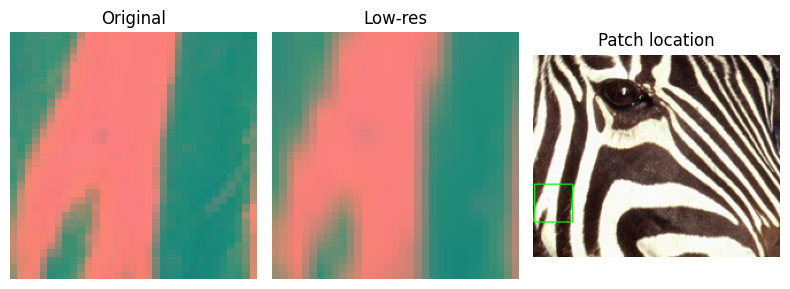

In [38]:
# Test the generation of patches from the original and low-resolution images using helper functions
patch_size = 33 
batch_size = 32
scale_factor = 3

train_path = "C:\\Users\\grega\\faks\\mag3\\nsso\\obdelava_slik_s_pytorch\\data\\image_upscale\\T91"
train_path_list = [os.path.join(train_path, f) for f in os.listdir(train_path)]

img_path = train_path_list[np.random.randint(0, len(train_path_list))] # random image from the T91 dataset
img = load_img_to_tensor(img_path)
img_numpy = torch.moveaxis(img, 0, 2).numpy()
img_org = convert_rgb_to_ycbcr(img)
img_lr = convert_img_to_low_res(img_org, scale_factor)
patch_lr, patch_org, x, y = generate_patches(img_org, img_lr, patch_size, 1)[0]

cv2.rectangle(img_numpy, (x, y), (x + patch_size, y + patch_size), (0, 255, 0), 1)
fig, ax = plt.subplots(1, 3, figsize=(8, 4))
ax[0].imshow(torch.moveaxis(patch_org, 0, 2).numpy())
ax[0].axis('off')
ax[0].set_title('Original')
ax[1].imshow(torch.moveaxis(patch_lr, 0, 2).numpy())
ax[1].axis('off')
ax[1].set_title('Low-res')
ax[2].imshow(img_numpy)
ax[2].axis('off')
ax[2].set_title('Patch location')
plt.tight_layout()
plt.show()

## Creating a Custom Dataset

In this step, we define a custom PyTorch `Dataset` class called `DataGenerator`. This class is designed to streamline the process of preparing training data for our super-resolution model. The dataset takes in a list of image file paths along with parameters such as patch size, scale factor, and the number of patches to extract per image. In the **constructor** (`__init__`), these parameter are stored as instance variables. The `__len__` method returns the total number of images available, which is essential for PyTorch to know how many samples it can iterate over. In the `__getitem__` method, we load the image from the given path using our helper function `load_img_to_tensor`, then convert it to the YCbCr color space with `convert_rgb_to_ycbcr`. Next, a low-resolution version of the image is generated using `convert_img_to_low_res` with the provided scale factor. Finally the dataset checks the `patch_size` parameter:
- if it is 0, the method returns the full low-resolution and original high-resolution images (useful for validation).
- otherwise, it extracts a specified number of random patches from the images using the `generate_patches` function and returns those patches. This flexible design allows for the same dataset class to be used for both training (with patch extraction) and validation (with full images).

In [5]:
class DataGenerator(torch.utils.data.Dataset):
    """
    A PyTorch Dataset for generating low-resolution and high-resolution image pairs, optionally extracting patches for training super-resolution models.

    This dataset loads images from a list of file paths, converts them to a specific color space, 
    generates low-resolution counterparts, and optionally extracts patches of a given size 
    for training. If `patch_size` is set to 0, the dataset returns full images, which is useful for validation.

    Args
    ----------
    path_list : list[str]
        A list of file paths to the source images.
    patch_size : int
        The size of the square patch to extract from each image. 
        If 0, no patches are extracted and full images are returned.
    scale_factor : int or float
        Factor by which to downscale the original images 
        to produce low-resolution versions.
    num_patches : int, optional
        The number of patches to generate per image. Defaults to 1.

    Attributes
    ----------
    path_list : list[str]
        The list of file paths to the images.
    patch_size : int
        The size of patches to extract from images.
    scale_factor : int or float
        The scaling factor for creating low-resolution images.
    num_patches : int
        The number of patches to generate per image.

    Methods
    ----------
        `__len__()`:
            Returns:
                int: The total number of images available in the dataset.

        `__getitem__`(index):
            Fetches the image (or patches) corresponding to the given index.
            
            Depending on `patch_size`, this method returns:
              - If `patch_size == 0`: A tuple `(img_lr, img_org)` where
                    - `img_lr` is the low-resolution version of the original image.
                    - `img_org` is the original high-resolution image.
              - If `patch_size > 0`: A set of patches generated from both the 
                                     low-resolution and original images.
            
            Args:
                index (int): The index of the image to fetch.
            
            Returns:
                tuple or list: If `patch_size == 0`, returns a tuple of tensors `(img_lr, img_org)`.
                               If `patch_size > 0`, returns a list of patch tuples or arrays.
    """

    def __init__(self, path_list, patch_size, scale_factor, num_patches=1):
        self.path_list = path_list
        self.patch_size = patch_size
        self.scale_factor = scale_factor
        self.num_patches = num_patches

    def __len__(self):
        return len(self.path_list)

    def __getitem__(self, index):
        img_path = self.path_list[index]
        img = load_img_to_tensor(img_path)
        img_org = convert_rgb_to_ycbcr(img)
        img_lr = convert_img_to_low_res(img_org, self.scale_factor)
        if self.patch_size == 0:  # for validation
            return img_lr, img_org

        patches = generate_patches(img_org, img_lr, self.patch_size, self.num_patches)
        return patches


## Initializing the DataLoader

Here, we set up another helper function called `init_data_loader` to create a PyTorch `DataLoader` that efficiently serves batches of data for training and validation. The function starts by creating a list of image file paths from the specified directory. To artificially expand the dataset, it replicates this list based on the `num_times_img` parameter. It then creates and instance of our custom `DataGenerator` using the provided parameters such as `patch_size`, `scale_factor`, and `num_patches`, which dictate how images or patches are generated from each file. Finally, the `DataLoader` is created with a specified `batch_size` and an option to shuffle the dataset. This design allows us to flexibly experiment with patch sizes and training parameters. Additionally, the code demonstrates how to retrieve a batch from the training loader, stack the patches, and reshape the tensors so that each patch is treated as an individual sample, making it ready for model training.

In [6]:
def init_data_loader(path : str, patch_size : int, scale_factor : int, num_patches : int, batch_size : int, shuffle : bool, num_times_img=1) -> torch.utils.data.DataLoader:
    """
    Initialize a PyTorch DataLoader with a custom DataGenerator for super-resolution tasks.

    This function creates a DataLoader that serves batches of image data for training or validation. 
    It constructs a list of image file paths from a given directory, possibly replicates them to 
    increase dataset size, and then uses a custom DataGenerator to produce low-resolution and 
    high-resolution image pairs (or patches) based on the specified parameters. Finally, 
    it wraps the DataGenerator in a DataLoader for batch processing.

    Args
    ----------
    `path` : str
        The directory path containing image files.
    `patch_size` : int
        The size of square patches to extract from each image. If set to 0, full images are used.
    `scale_factor` : int or float
        The factor by which to downscale images to generate low-resolution versions.
    `num_patches` : int
        The number of patches to generate from each image.
    `batch_size` : int
        The number of samples per batch to load.
    `shuffle` : bool
        Whether to shuffle the dataset after each epoch.
    `num_times_img` : int, optional
        The number of times to replicate the list of image paths to artificially enlarge the dataset.
        Defaults to 1.

    Returns
    ----------
    torch.utils.data.DataLoader
        A DataLoader object that yields batches of data from the DataGenerator.

    Notes
    ----------
    - The function assumes that the directory specified by `path` contains image files.
    - The DataGenerator used inside the DataLoader handles image loading, conversion to 
      appropriate color space, downscaling, and patch generation.
    - If `patch_size` is set to 0, the DataGenerator returns full-resolution and low-resolution 
      image pairs, which is typically used for validation rather than patch-based training.
    """
    path_list = [os.path.join(path, f) for f in os.listdir(path)]
    path_list = path_list * num_times_img
    data_generator = DataGenerator(path_list, patch_size, scale_factor, num_patches)
    data_loader = torch.utils.data.DataLoader(data_generator, batch_size=batch_size, shuffle=shuffle, pin_memory=True)
    return data_loader


train_path = "C:\\Users\\grega\\faks\\mag3\\nsso\\obdelava_slik_s_pytorch\\data\\image_upscale\\T91"
train_data_loader = init_data_loader(
    path=train_path, 
    patch_size=33, 
    scale_factor=2, 
    num_patches=10, # per image
    batch_size=32, 
    shuffle=True, 
    num_times_img=3
)

val_path = 'C:\\Users\\grega\\faks\\mag3\\nsso\\obdelava_slik_s_pytorch\\data\\image_upscale\\Set5' # 'C:\\Users\\grega\\faks\\mag3\\nsso\\obdelava_slik_s_pytorch\\data\\image_upscale\\Set14'
val_data_loader = init_data_loader(
    path=val_path, 
    patch_size=0, 
    scale_factor=2,
    num_patches=0,
    batch_size=1,
    shuffle=False
)

patches = next(iter(train_data_loader))
batch_lr = torch.stack([patch[0] for patch in patches])
batch_hr = torch.stack([patch[1] for patch in patches])
print(np.shape(batch_hr)) # num_patches, batch_size, 3, 33, 33

batch_lr = batch_lr.view(-1, 3, 33, 33)
batch_hr = batch_hr.view(-1, 3, 33, 33)
print(np.shape(batch_hr)) # num_patches, batch_size, 3, 33, 33

torch.Size([10, 32, 3, 33, 33])
torch.Size([320, 3, 33, 33])


## Defining the Super-Resolution Model

In the next, very important step, we define our super-resolution network using a simple CNN architecture. This model is designed for grayscale (luminance-only) images and is inspired by pioneering approaches such as SRCNN, which laid the foundation for more complex architectures.

### The Model Architecture

Our model, named `SuperResConvNeuralNet`, comprises three convolutional layers.

1. **First Convolutional Layer:**
   - **Operation:** Applies 64 filters (or kernels) of size 9×9 to the input image.
   - **Purpose:** The large kernel size helps capture a broad context from the input image by covering a larger receptive field.
   - **Parameters:** Each filter has learnable weights and an associated bias. For a 9×9 kernel applied to a single-channel input, each filter contains 9×9 weights plus 1 bias. With 64 such filters, this layer has a total of 5248 parameters.
   - **Output:** Produces 64 feature maps of the same spatial dimensions (33×33) as the input, thanks to the `'same'` padding.

2. **Second Convolutional Layer:**
   - **Operation:** Applies 32 filters of size 5×5 on the 64-channel output from the previous layer.
   - **Purpose:** This layer refines and compresses the feature representation extracted by the first layer. The smaller 5×5 kernel focuses on local patterns while still preserving spatial resolution.
   - **Parameters:** With 32 filters each operating on 64 input channels, plus biases, this layer has 51232 parameters.
   - **Output:** Produces 32 feature maps of size 33×33.

3. **Third Convolutional Layer:**
   - **Operation:** Applies a single 5×5 filter to map the refined 32-channel feature maps back to a single-channel output.
   - **Purpose:** This final mapping reconstructs the high-resolution luminance image.
   - **Parameters:**  With 32 input channels and a 5×5 kernel (plus a bias), this layer contains 801 parameters.
   - **Output:** Yields a final single-channel image of size 33×33.

Between the convolutional layers, **ReLU** (Rectified Linear Unit) activations are applied. ReLU introduces non-linerity into the network, allowing it to learn complex relationships between low-resolution and high-resolution images. Notice that we deliberately leave out any activation after the last convolution to ensure that the network can output continous pixel values.

```{note}
**Understanding Filters, Weights, and Biases**

- **Filters (Kernels):**
These are small matrices (e.g., 9×9 or 5×5) that slide over the input image. Each filter is designed to capture specific features such as edges, textures, or patterns. In our model, the first layer's filters capture broad contextual features, while subsequent layers refine them.

- **Weights:**
The individual values in each filter are learnable parameters (weights) that determine how much influence each pixel in the receptive field has on the output. During traning, these weights are adjusted so that the network learns the optimal representation for reconstructing high-resolution images.

- **Biases:**
Each filter has an associated bias term. The bias allows for activation of a neuron to be shifted, providing additional flexibility to the model. It ensures that even when the weighted sum of inputs is zero, the neuron can still have a non-zero output.

Together, the weights and biases form the core of the learning process. The network adjusts these parameters during training to minimize a loss function (such as mean squared error), thereby improving the quality of the super-resolved images.
```

In [7]:
class SuperResConvNeuralNet(torch.nn.Module):
    """
    A convolutional neural network for single-channel image super-resolution.

    This network uses three convolutional layers with ReLU activations to learn the 
    mapping from a low-resolution input image to a higher-resolution output image.
    The architecture is designed to process grayscale (single-channel) images.

    Architecture
    ----------
    - Conv1: 
        - Input channels: 1
        - Output channels: 64
        - Kernel size: 9x9
        - Padding: 'same' (output spatial dimensions remain the same as input)
        - Activation: ReLU
    - Conv2:
        - Input channels: 64
        - Output channels: 32
        - Kernel size: 5x5
        - Padding: 'same'
        - Activation: ReLU
    - Conv3:
        - Input channels: 32
        - Output channels: 1
        - Kernel size: 5x5
        - Padding: 'same'
        - No activation after this layer (output layer)

    Methods
    ----------
    forward(x: torch.Tensor) -> torch.Tensor
        Defines the forward pass of the network.
        
        Args
        ----------
        x : torch.Tensor
            A tensor representing a batch of grayscale images, 
            with shape (batch_size, 1, height, width).
        
        Returns
        ----------
        torch.Tensor
            The super-resolved output images after processing through the network,
            with the same spatial dimensions as the input due to padding='same'.
    """

    def __init__(self):
        super(SuperResConvNeuralNet, self).__init__()
        self.conv1 = torch.nn.Conv2d(in_channels=1, out_channels=64, kernel_size=9, padding='same')
        self.conv2 = torch.nn.Conv2d(in_channels=64, out_channels=32, kernel_size=5, padding='same')
        self.conv3 = torch.nn.Conv2d(in_channels=32, out_channels=1, kernel_size=5, padding='same')
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.conv3(x)
        return x

# Instantiate the model and print its summary
model = SuperResConvNeuralNet()
print(torchinfo.summary(model, [1, 1, 33, 33]))


Layer (type:depth-idx)                   Output Shape              Param #
SuperResConvNeuralNet                    [1, 1, 33, 33]            --
├─Conv2d: 1-1                            [1, 64, 33, 33]           5,248
├─ReLU: 1-2                              [1, 64, 33, 33]           --
├─Conv2d: 1-3                            [1, 32, 33, 33]           51,232
├─ReLU: 1-4                              [1, 32, 33, 33]           --
├─Conv2d: 1-5                            [1, 1, 33, 33]            801
Total params: 57,281
Trainable params: 57,281
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 62.38
Input size (MB): 0.00
Forward/backward pass size (MB): 0.85
Params size (MB): 0.23
Estimated Total Size (MB): 1.08


![Model representation](./model_representation.png)

The model summary output (obtained via `torchinfo.summary`) provides a detailed look at each layer's output shape and parameter count, confirming that our network has a total of 57281 trainable parameters and maintains the input dimensions throughout the forward pass.

## Training Function

The next step is where we implement the training routine for our super-resolution model. The `nn_train` function encapsulates the entire training process, including both the **forward pass** and **backward propagation**, as well as **validation**, checkpointing, and early stopping mechanisms.

During each epoch, the model is set to training mode using `model.train()`, which ensures that layers like dropout or batch normalization behave correctly during training. The function then iterates over the batches provided by the training **DataLoader**. For each batch, low-resolution and high-resolution patches are stacked together and reshaped so that the model treats each patch as an individual sample. Because our network is designed to work on luminance (Y) channel of images (i.e., grayscale), we select only the first channel from each patch before feeding it into the model.

The **forward pass** is performed by calling the model with the low-resolution input. This pass computes the output (predicted high-resolution image) by propagating the input through each layer of the network. The difference between this output and the ground truth high-resolution image is measured using a loss function - in our case, the Mean Squared Error (MSE) loss. MSE is chosen because it provides a straight forward measure of the average squared difference between the predicted pixel values and the true values, and it has been traditionally used in image restoration tasks despite its tendency to produce smooth (sometimes overly smoothed) images.

After computing the loss, the **backward propagation** step computes gradients of the loss with respect to each learnable parameter in the network. This is achieved by calling `loss.backward()`. The optimizer (e.g., Adam, which adapts learning rates for each parameter) then uses these gradients to update the model's parameters via `optimizer.step()`. This iterative process of forward and backward passes gradually adjusts the weights to minimize the loss.

Following the training phase of each epoch, the function swithces the model to evaluation mode using `model.eval()`. In this phase, no gradients are comptued (using the `torch.no_grad()` context) so that the model's performance on the validation set can be measured without affecting the model's parameters. The validation loop computes both the average loss and the PSNR for the validation data. PSNR is a key metric in super-resolution tasks as it provides a quantitative measure of how closely the reconstructed images match the original high-resolution images.

The training loop includes two important mechanisms for efficient model training:
- **Checkpointing:** The model's state is saved `save_every` epochs, which ensures that progress is not lost and provides a way to recover or resume training from intermediate points.
- **Early Stopping:** If the validation loss does not improve my at least `min_delta` for a specified number of consecutive epochs (`patience`), training is terminated early. This prevents overfitting and saves computational resources when the model stops learning.

Finally, the function plots the training loss over all iterations, providing a visual representation of how the model's performance evolves during training. This complete training routine is essential for long-running experiments and ensures that the model is trained efficiently with proper monitoring of its performance.

In [8]:
def nn_train(model: torch.nn.Module, 
             train_data_loader: torch.utils.data.DataLoader, 
             val_data_loader: torch.utils.data.DataLoader, 
             num_epochs: int, 
             optimizer: torch.optim.Optimizer,
             loss_fn: callable, 
             device: torch.device,
             save_every: int = 50,
             patience: int = 100,
             min_delta: float = 1e-4):
    """
    Train a neural network model for image super-resolution with periodic checkpointing and early stopping.

    This function iteratively trains the given model using the provided training data loader,
    computes training loss, and evaluates the model on a validation set to compute validation
    loss and PSNR (Peak Signal-to-Noise Ratio). It saves model checkpoints every `save_every` epochs
    and implements early stopping if the validation loss does not improve by at least `min_delta`
    for `patience` consecutive epochs.

    Args
    ----------
    model : torch.nn.Module
        The neural network model to be trained.
    train_data_loader : torch.utils.data.DataLoader
        DataLoader providing training data batches, where each batch contains pairs of 
        low-resolution and high-resolution image patches.
    val_data_loader : torch.utils.data.DataLoader
        DataLoader providing validation data batches of low-resolution and high-resolution 
        image pairs.
    num_epochs : int
        The number of epochs (complete passes through the training dataset) to train for.
    optimizer : torch.optim.Optimizer
        The optimization algorithm to use for updating model weights (e.g., Adam).
    loss_fn : callable
        The loss function to minimize during training (e.g., mean squared error).
    device : torch.device
        The device on which to train the model (e.g., CPU or CUDA GPU).
    save_every : int, optional
        Frequency (in epochs) to save the model checkpoint. Defaults to 50.
    patience : int, optional
        The number of consecutive epochs to wait for a significant improvement in validation loss before stopping early. Defaults to 100.
    min_delta : float, optional
        The minimum decrease in validation loss to qualify as an improvement. Defaults to 1e-4.

    Returns
    ----------
    None

    Notes
    ----------
    - The function modifies the model's parameters in place.
    - Training loss for every batch is recorded and plotted after all epochs.
    - Validation is performed after each epoch, computing both loss and PSNR.
    - Progress messages are printed every 20 epochs with metrics:
        - Average training loss
        - Average validation loss
        - Average and maximum PSNR on the validation set
    - Model checkpoints are saved every `save_every` epochs.
    - Early stopping is triggered when validation loss does not improve by at least `min_delta`
      for `patience` consecutive epochs.
    """
    losses = []
    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        print(f"Epoch: {epoch + 1}")
        for patches in train_data_loader:
            batch_lr = torch.stack([patch[0] for patch in patches]).to(device)
            batch_hr = torch.stack([patch[1] for patch in patches]).to(device)

            # Reshape: combine the patch and batch dimensions.
            batch_lr = batch_lr.view(-1, 3, 33, 33)
            batch_hr = batch_hr.view(-1, 3, 33, 33)
            
            # Use only the Y channel (grayscale) for training.
            batch_lr = batch_lr[:, 0:1, :, :]
            batch_hr = batch_hr[:, 0:1, :, :]

            optimizer.zero_grad()
            output = model(batch_lr)
            loss = loss_fn(output, batch_hr)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        # Evaluate on the validation set.
        model.eval()
        val_losses = []
        val_psnrs = []
        with torch.no_grad():
            for batch_lr, batch_hr in val_data_loader:
                batch_lr = batch_lr[:, 0:1, :, :].to(device)
                batch_hr = batch_hr[:, 0:1, :, :].to(device)

                output = model(batch_lr)
                loss = loss_fn(output, batch_hr)
                val_losses.append(loss.item())

                val_psnr = calculate_psnr(batch_hr, output)
                val_psnrs.append(val_psnr)

        avg_val_loss = np.mean(val_losses)

        # Check for improvement in validation loss.
        if avg_val_loss + min_delta < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            print(f"Epoch {epoch + 1}: New best validation loss: {avg_val_loss:.4f}")
        else:
            epochs_no_improve += 1
            print(f"Epoch {epoch + 1}: No significant improvement for {epochs_no_improve} epochs.")

        # Early stopping condition.
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch + 1} epochs.")
            break

        # Print progress every 20 epochs.
        if (epoch + 1) % 20 == 0:
            print(f"{epoch + 1}/{num_epochs}: Train loss: {np.mean(losses):.4f}, "
                  f"Val loss: {avg_val_loss:.4f}, Val PSNR: {np.mean(val_psnrs):.2f}, "
                  f"Max PSNR: {np.max(val_psnrs):.2f}")

        # Save a checkpoint every 'save_every' epochs.
        if (epoch + 1) % save_every == 0:
            torch.save(model.state_dict(), f"./model_checkpoints/model_epoch_{epoch + 1}_sf_{scale_factor}.pth")
            print(f"Saved model checkpoint at epoch {epoch + 1}.")

    # Plot training loss over iterations.
    plt.plot(losses)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Time')
    plt.show()


This training function is central to our tutorial, providing a clear and detailed example of how to train, monitor, and evaluate a super-resolution model using PyTorch. It covers all the essential elements of deep learning training - from forward pass and back propagation to practical considerations like early stopping and checkpointing. 

## Setting the Training Device

In this block, we determine whether a CUDA-compatible GPU is available and set the training device accordingly. Running deep learning models on a GPU can significantly speed up training due to its ability to handle parallel computations efficiently, which is particularly beneficial for large models and datasets. If no GPU is available, the code gracefully falls back to using the CPU. GPU training requires a CUDA-enabled NVIDIA GPU with proper drivers installed.

In [9]:
# Define the device to train the model on: use 'cuda' if available, otherwise fall back to 'cpu'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on device: {device}")

if device.type == 'cuda':
    print("CUDA is available!")
    # Print additional GPU details.
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("CUDA Version:", torch.version.cuda)
    print("Number of CUDA Devices:", torch.cuda.device_count())
    print("Current CUDA Device Index:", torch.cuda.current_device())
else:
    print("CUDA is not available. Using CPU. Note that training on CPU can be significantly slower for deep learning tasks.")

Training on device: cuda
CUDA is available!
GPU Name: NVIDIA GeForce RTX 3050 Ti Laptop GPU
CUDA Version: 12.4
Number of CUDA Devices: 1
Current CUDA Device Index: 0


```{admonition} Note
:class: important
**Note on Hardware**

As said, GPU leverages the parallel processing power of a CUDA-enabled NVIDIA GPU, which can lead to drastic speed improvements in training time compared to a CPU. However, the combination of our lightweight model, small batch sizes, and CPU-bound data preparation can lead to low overall GPU utilization in our case. Reader is encouraged to play around with adjusting the batch size parameter, DataLoader settings, and possibly prefetching data to see a higher GPU utilization.
```

## Training the Model

In this step, we bring together all preceding steps to actually train our super-resolution model. First, we define the optimizer and loss function. Here, we choose **Adam** opzimizer with a learning rate of 0.0001, a popular choice for its adaptive learning capabilities, and the MSE loss function, which is commonly used in regression tasks like super-resolution to quantify the difference between the predicted and ground truth images.

Next, we set the number of epochs, patch size, and scale factor for our experiments. We then initialize the training and validation DataLoaders using our custom `init_data_loader` function which ensures that the data is properly preprocessed and fed into the network in the form of low-resolution image pairs (or patches). The training DataLoader is configured to randomly shuffle the images and to repeat the dataset a specified number of times to enhance training variety, while the validation DataLoader is set up to provide full images without shuffling.

After moving the model to the appropriate device, we call the `nn_train` function, which executes the training loop for the specified number of epochs, monitors the loss, implements early stopping and checkpointing, and prints out the training progress. Once training is complete, the final model state is saved to disk, ensuring the training model can be reused or evaluated later.

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
loss_fn = torch.nn.MSELoss()

num_epochs = 300
patch_size=33
scale_factor=2

train_path = "C:\\Users\\grega\\faks\\mag3\\nsso\\obdelava_slik_s_pytorch\\data\\image_upscale\\T91"
train_data_loader = init_data_loader(train_path, patch_size, scale_factor, num_patches=10, batch_size=32, shuffle=True, num_times_img=3)
val_path = 'C:\\Users\\grega\\faks\\mag3\\nsso\\obdelava_slik_s_pytorch\\data\\image_upscale\\Set5' # 'C:\\Users\\grega\\faks\\mag3\\nsso\\obdelava_slik_s_pytorch\\data\\image_upscale\\Set14'
val_data_loader = init_data_loader(val_path, patch_size=0, scale_factor=scale_factor, num_patches=1, batch_size=1, shuffle=False)

model = model.to(device)
nn_train(model, train_data_loader, val_data_loader, num_epochs, optimizer, loss_fn, device)
torch.save(model.state_dict(), f'model_scale_factor_{scale_factor}.pth')

![Model loss](./model_loss.png)

```{note}
In this final plot we see that the model is trained very quickly and the number of epochs can be reduced even further. Here, the reader is further encouraged to play around with the settings and compare different training outputs.
```


## Evaluation Function

In this final evaluation step, we define a function `nn_eval` that processes a list of test image file paths and provides both qualitative and quantitative feedback on model's performance. The function first loads each high-resolution image and generates a corresponding low-resolution version using our earlier helper functions. It then converts both images from RGB to YCbCr color space. The low-resolution image's Y channel is fed into the network to produe a predicted high-resolution Y channel. The output is then combined with the original Cb and Cr channels and converted back to the RGB color space to reconstruct a full-color image.

After reconstruction, the function calculates key quality metrics, including the Peak Signal-to-Noise Ratio (PSNR) and the Structural Similarity Index (SSIM), comparing both the predicted image and the low-resolution input against the original high-resolution image. For a more detailed examination, the function randomly selects a region of the image (defined by a zoom size and position) and displays side-by-side comparisons of the full images and the cropped regions, each annotated with the computed PSNR and SSIM values.

In [10]:
def nn_eval(model : torch.nn.Module, path_list : list, device : torch.device):
    """
    Evaluate a trained super-resolution model on a list of image files and display qualitative and quantitative results.
    
    This function processes each image specified in `path_list` by performing the following steps:
    
    1. **Image Loading and Preprocessing:**  
       - Loads the original high-resolution image using `load_img_to_tensor`.  
       - Generates a corresponding low-resolution image via `convert_img_to_low_res` (using a global or externally defined scale factor).  
       - Converts both the original and low-resolution images from RGB to YCbCr color space using `convert_rgb_to_ycbcr` and moves them to the specified device.
    
    2. **Model Inference:**  
       - Extracts the Y channel (luminance) from both images and prepares the low-resolution Y channel as input by adding a batch dimension.  
       - Feeds the low-resolution Y channel into the model to obtain a predicted (super-resolved) Y channel output.
       - Concatenates the predicted Y channel with the original Cb and Cr channels (from the original image) to reconstruct a full YCbCr image.
    
    3. **Post-processing:**  
       - Converts the predicted YCbCr output as well as the low-resolution and original images back to RGB using `convert_ycbcr_to_rgb`.  
       - Clamps and normalizes the output to ensure pixel values are within [0, 1].  
       - Transposes the image arrays to the (H, W, C) format for visualization.
    
    4. **Metric Calculation:**  
       - Computes the Peak Signal-to-Noise Ratio (PSNR) between the original and the predicted images using `calculate_psnr`.  
       - Computes the Structural Similarity Index (SSIM) using `skimage.metrics.structural_similarity` with parameters `win_size=5`, `channel_axis=-1`, and `data_range=1.0` (assuming images are normalized to [0, 1]).  
       - Also computes PSNR and SSIM for the low-resolution image relative to the original image.
    
    5. **Visualization:**  
       - Randomly selects a zoom area and displays three side-by-side figures:
         - **Full Image Comparison:** Shows the low-resolution, predicted, and original images with a red rectangle marking the zoomed region.
         - **Cropped Comparison:** Displays the zoomed region from each image for a closer inspection.
       - Prints the computed PSNR and SSIM values for each image.
    
    Args
    ----------
    model : torch.nn.Module  
        The trained super-resolution model to evaluate.
    path_list : list of str  
        A list of file paths to the images to be evaluated.
    device (torch.device):  
        The device (CPU or GPU) on which to perform the evaluation.
    
    Returns
    ----------
        None.  
        The function displays plots for visual inspection and prints the PSNR and SSIM metrics.
    
    Notes
    ----------
    - This function assumes that helper functions such as `load_img_to_tensor`, `convert_img_to_low_res`,  
        `convert_rgb_to_ycbcr`, `convert_ycbcr_to_rgb`, and `calculate_psnr` are available and properly implemented.
    - The scale factor used in `convert_img_to_low_res` is assumed to be defined externally (e.g., as a global variable or passed in elsewhere).
    - The SSIM computation uses `channel_axis=-1` to specify that the color channels are in the last axis.
    """
    for path in path_list:
        img_org = load_img_to_tensor(path)
        img_lr = convert_img_to_low_res(img_org, scale_factor)

        img_org = convert_rgb_to_ycbcr(img_org).to(device)
        img_lr = convert_rgb_to_ycbcr(img_lr).to(device)

        img_org_y = img_org[0:1]
        img_lr_y = img_lr[0:1]

        img_lr_y = img_lr_y.unsqueeze(0)
        img_lr_y = img_lr_y.to(device)

        output = model(img_lr_y)
        output = output.squeeze(0)
        output = torch.concat([output, img_org[1:3]])
        output = torch.tensor(convert_ycbcr_to_rgb(output.cpu().detach().numpy()))
        output = output.clamp(0, 1).cpu().detach().numpy()
        img_lr = convert_ycbcr_to_rgb(img_lr.cpu().detach().numpy())
        img_org = convert_ycbcr_to_rgb(img_org.cpu().detach().numpy())

        img_org = img_org.transpose(1, 2, 0)
        img_lr = img_lr.transpose(1, 2, 0)
        output = output.transpose(1, 2, 0)

        psnr = calculate_psnr(img_org, output)
        ssim, ssim_map = skimage.metrics.structural_similarity(
            img_org,
            output,
            win_size=5,
            channel_axis=-1,
            data_range=1.0,
            full=True
        )

        psnr_lr = calculate_psnr(img_org, img_lr)
        ssim_lr, ssim_map_lr = skimage.metrics.structural_similarity(
            img_org,
            img_lr,
            win_size=5,
            channel_axis=-1,
            data_range=1.0,
            full=True
        )

        zoom_size = np.random.randint(50, 150)
        random_pos = np.random.randint(0, 256 - zoom_size)

        fig, ax = plt.subplots(1, 3, figsize=(16, 8))
        ax[0].imshow(img_lr)
        rect = Rectangle((random_pos, random_pos), zoom_size, zoom_size, linewidth=2, edgecolor='red', facecolor='none')
        ax[0].add_patch(rect)
        ax[0].axis('off')
        ax[0].set_title(f'Low-res, PSNR: {psnr_lr:.2f}, SSIM: {ssim_lr:.2f}')

        ax[1].imshow(output)
        rect = Rectangle((random_pos, random_pos), zoom_size, zoom_size, linewidth=2, edgecolor='red', facecolor='none')
        ax[1].add_patch(rect)
        ax[1].axis('off')
        ax[1].set_title('Prediction, PSNR: {:.2f}, SSIM: {:.2f}'.format(psnr, ssim))

        ax[2].imshow(img_org)
        rect = Rectangle((random_pos, random_pos), zoom_size, zoom_size, linewidth=2, edgecolor='red', facecolor='none')
        ax[2].add_patch(rect)
        ax[2].axis('off')
        ax[2].set_title('Original')

        plt.tight_layout()
        plt.show()

        fig, ax = plt.subplots(1, 3, figsize=(16, 8))
        img_lr_crop = img_lr[random_pos:random_pos + zoom_size, random_pos:random_pos + zoom_size, :]
        output_crop = output[random_pos:random_pos + zoom_size, random_pos:random_pos + zoom_size, :]
        img_org_crop = img_org[random_pos:random_pos + zoom_size, random_pos:random_pos + zoom_size, :]

        ax[0].imshow(img_lr_crop)
        ax[0].axis('off')
        ax[0].set_title(f'Low-res, PSNR: {psnr_lr:.2f}, SSIM: {ssim_lr:.2f}')

        ax[1].imshow(output_crop)
        ax[1].axis('off')
        ax[1].set_title('Prediction, PSNR: {:.2f}, SSIM: {:.2f}'.format(psnr, ssim))

        ax[2].imshow(img_org_crop)
        ax[2].axis('off')
        ax[2].set_title('Original')

        plt.tight_layout()
        plt.show()

        print(f"PSNR: {psnr:.2f}, SSIM: {ssim:.2f}")


## Running Evaluation on Test Datasets

In the final block, we load our trained model from disk, set it to evaluation mode, and run it on unseen test data. We first instantiate the model and load the saved weights corresponding to our chosen scale factor. Then, we set the model to the correct device (GPU or CPU) and switch it to evaluation mode using model.eval(), ensuring that layers like dropout behave deterministically. Next, we gather image file paths from two test directories (for example, the Set5 and Set14 datasets) and combine them into a single list. Finally, we call our `nn_eval` function to process each test image, generate super-resolved predictions, compute quality metrics (PSNR and SSIM), and visualize the results both in full image and zoomed-in views.

Here we have results for two different scale factors.

### Results for scale_factor=2

C:\Users\grega\AppData\Local\Temp\ipykernel_6704\1568777528.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'model_scale_factor_{scale_

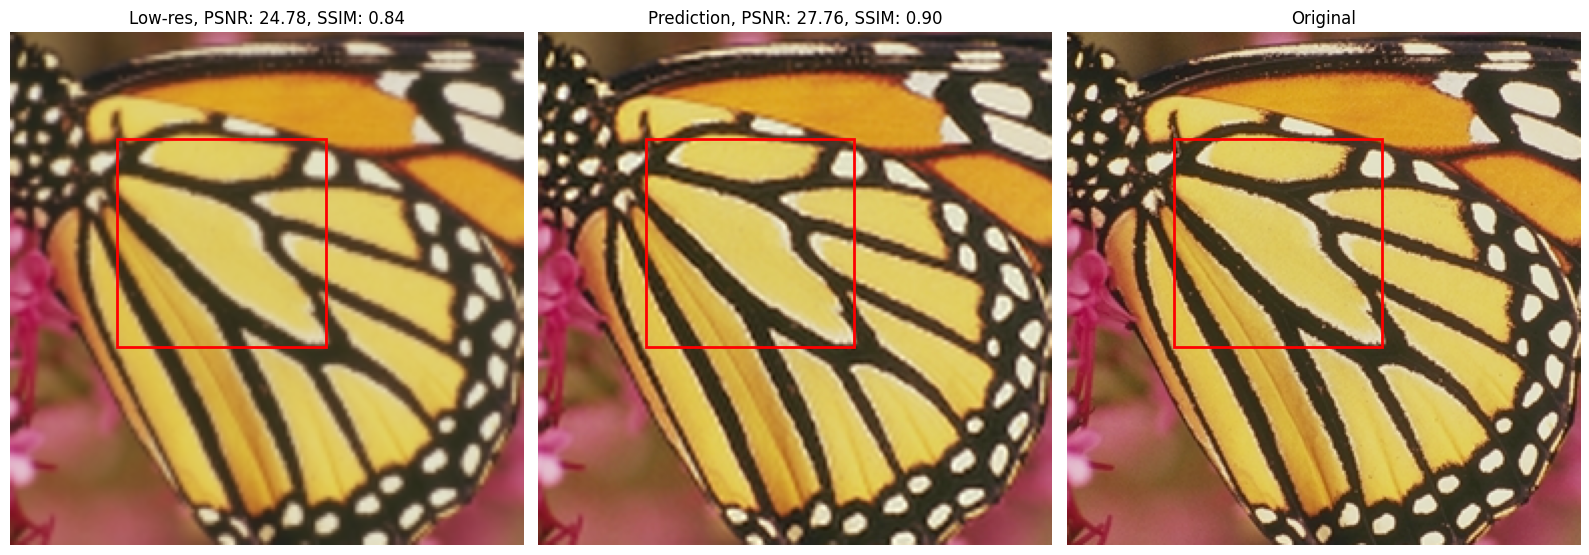

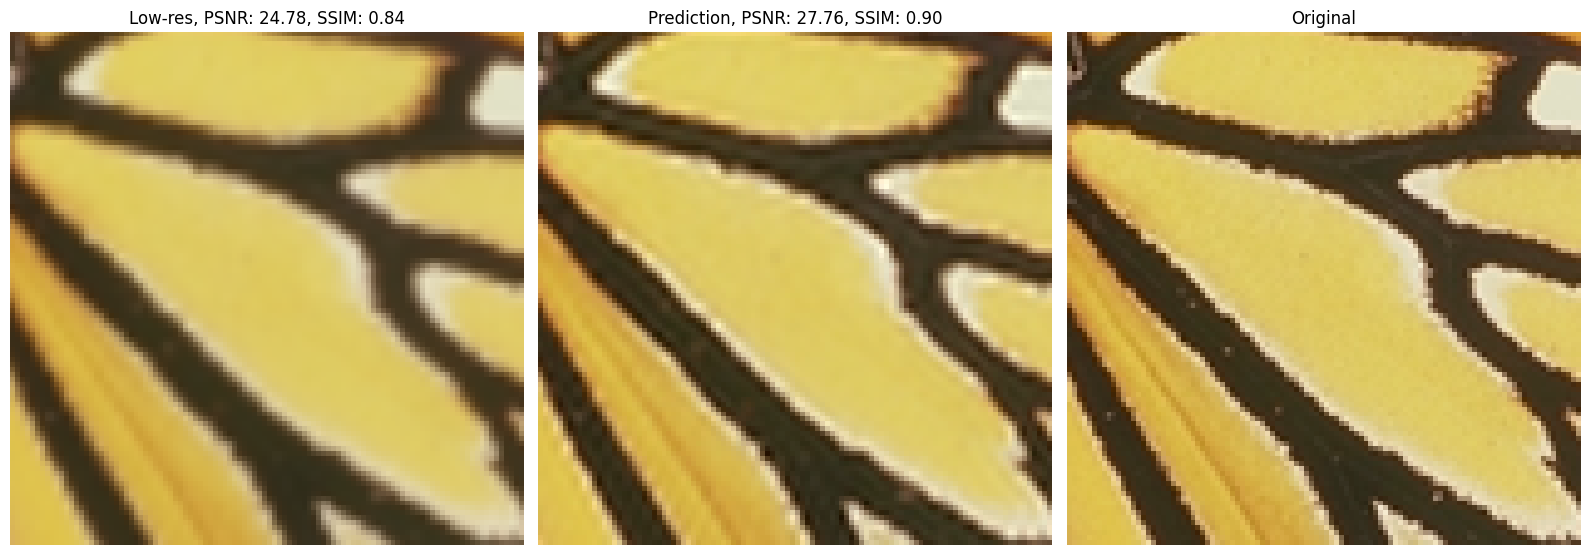

PSNR: 27.76, SSIM: 0.90
Average PSNR over test set: 27.76 dB
Average SSIM over test set: 0.8961


In [11]:
model = SuperResConvNeuralNet()
scale_factor = 2
model.load_state_dict(torch.load(f'model_scale_factor_{scale_factor}.pth'))
model.to(device)
model.eval()

#test_path_1 = 'C:\\Users\\grega\\faks\\mag3\\nsso\\obdelava_slik_s_pytorch\\data\\image_upscale\\Set5'
#test_path_2 = 'C:\\Users\\grega\\faks\\mag3\\nsso\\obdelava_slik_s_pytorch\\data\\image_upscale\\Set14'
test_path_1 = 'C:\\Users\\grega\\faks\\mag3\\nsso\\obdelava_slik_s_pytorch\\data\\image_upscale\\metulj'
test_path_list = [os.path.join(test_path_1, f) for f in os.listdir(test_path_1)]
#test_path_list += [os.path.join(test_path_2, f) for f in os.listdir(test_path_2)]

nn_eval(model, test_path_list, device)

# Calculate average PSNR and SSIM for all images in the test set
total_psnr = 0.0
total_ssim = 0.0
num_images = len(test_path_list)

for path in test_path_list:
    # Load the original high-resolution image and generate a low-resolution version.
    img_org = load_img_to_tensor(path)
    img_lr = convert_img_to_low_res(img_org, scale_factor)

    # Convert both images to YCbCr color space and move them to the device.
    img_org = convert_rgb_to_ycbcr(img_org).to(device)
    img_lr = convert_rgb_to_ycbcr(img_lr).to(device)

    # Extract the Y (luminance) channel and prepare the low-res image for model input.
    img_lr_y = img_lr[0:1].unsqueeze(0).to(device)
    
    # Forward pass: get the predicted high-res Y channel.
    output = model(img_lr_y)
    output = output.squeeze(0)
    
    # Reconstruct the full image by concatenating the predicted Y channel with the original Cb and Cr channels.
    output = torch.concat([output, img_org[1:3]])
    output = torch.tensor(convert_ycbcr_to_rgb(output.cpu().detach().numpy()))
    output = output.clamp(0, 1).cpu().detach().numpy()
    
    # Convert the original image back to RGB.
    img_org = convert_ycbcr_to_rgb(img_org.cpu().detach().numpy())

    # Transpose images from (C, H, W) to (H, W, C) for metric computation.
    img_org = img_org.transpose(1, 2, 0)
    output = output.transpose(1, 2, 0)
    
    # Compute PSNR and SSIM between the predicted image and the original high-resolution image.
    psnr = calculate_psnr(img_org, output)
    ssim, _ = skimage.metrics.structural_similarity(
                    img_org,
                    output,
                    win_size=5,
                    channel_axis=-1,
                    data_range=1.0,
                    full=True
                )
    
    total_psnr += psnr
    total_ssim += ssim

# Calculate average metrics over all test images.
avg_psnr = total_psnr / num_images
avg_ssim = total_ssim / num_images

print(f"Average PSNR over test set: {avg_psnr:.2f} dB")
print(f"Average SSIM over test set: {avg_ssim:.4f}")


### Results for scale_factor=3

C:\Users\grega\AppData\Local\Temp\ipykernel_6704\255716814.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'model_scale_factor_{scale_f

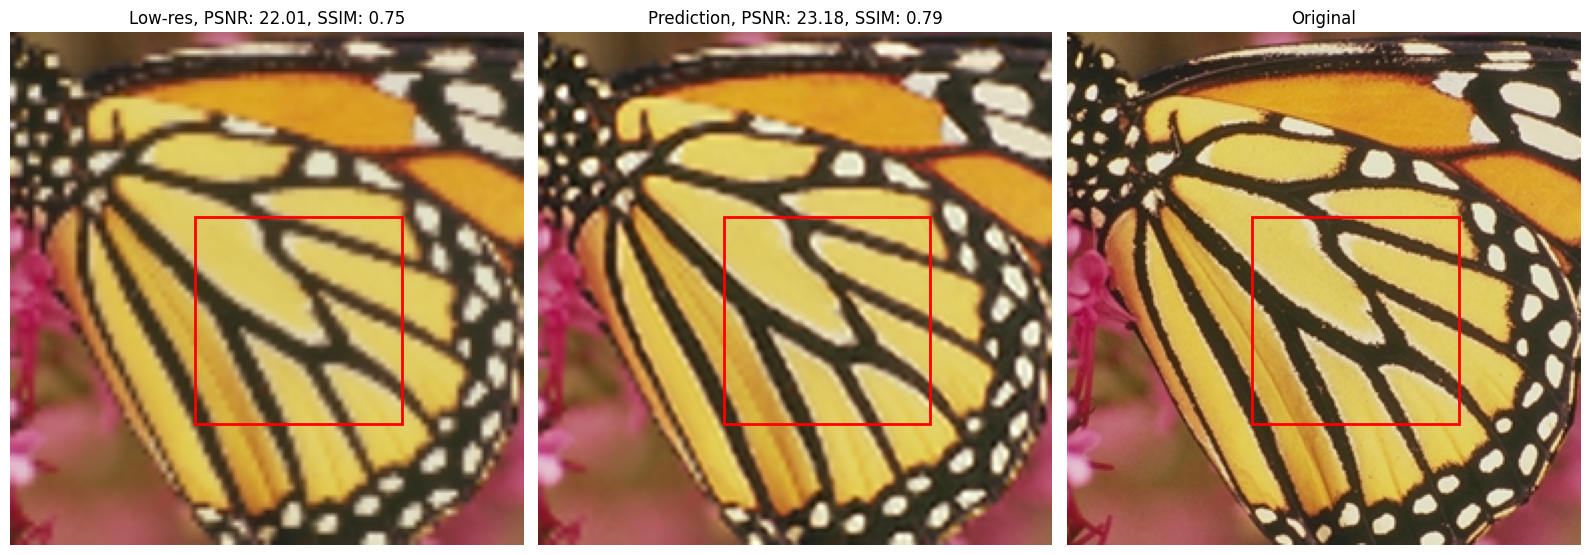

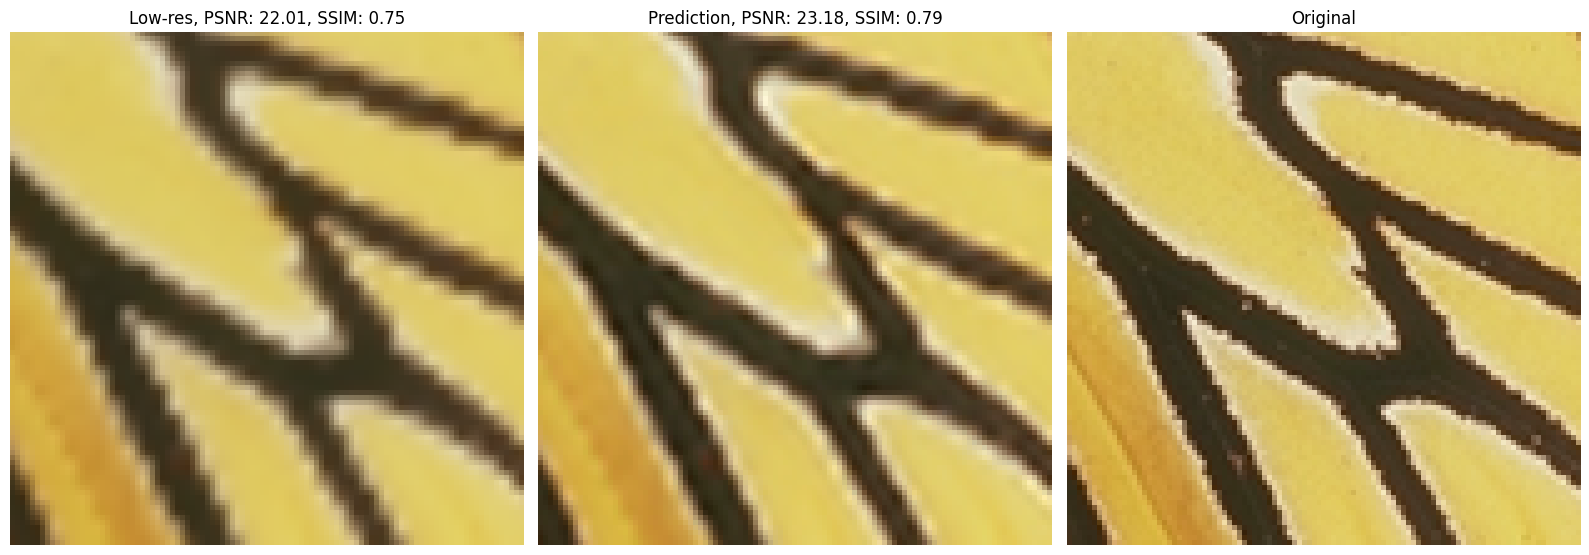

PSNR: 23.18, SSIM: 0.79
Average PSNR over test set: 23.18 dB
Average SSIM over test set: 0.7913


In [12]:
model = SuperResConvNeuralNet()
scale_factor = 3

model.load_state_dict(torch.load(f'model_scale_factor_{scale_factor}.pth'))
model.to(device)
model.eval()

#test_path_1 = 'C:\\Users\\grega\\faks\\mag3\\nsso\\obdelava_slik_s_pytorch\\data\\image_upscale\\Set5'
#test_path_2 = 'C:\\Users\\grega\\faks\\mag3\\nsso\\obdelava_slik_s_pytorch\\data\\image_upscale\\Set14'
test_path_1 = 'C:\\Users\\grega\\faks\\mag3\\nsso\\obdelava_slik_s_pytorch\\data\\image_upscale\\metulj'
test_path_list = [os.path.join(test_path_1, f) for f in os.listdir(test_path_1)]
#test_path_list += [os.path.join(test_path_2, f) for f in os.listdir(test_path_2)]

nn_eval(model, test_path_list, device)

# Calculate average PSNR and SSIM for all images in the test set
total_psnr = 0.0
total_ssim = 0.0
num_images = len(test_path_list)

for path in test_path_list:
    # Load the original high-resolution image and generate a low-resolution version.
    img_org = load_img_to_tensor(path)
    img_lr = convert_img_to_low_res(img_org, scale_factor)

    # Convert both images to YCbCr color space and move them to the device.
    img_org = convert_rgb_to_ycbcr(img_org).to(device)
    img_lr = convert_rgb_to_ycbcr(img_lr).to(device)

    # Extract the Y (luminance) channel and prepare the low-res image for model input.
    img_lr_y = img_lr[0:1].unsqueeze(0).to(device)
    
    # Forward pass: get the predicted high-res Y channel.
    output = model(img_lr_y)
    output = output.squeeze(0)
    
    # Reconstruct the full image by concatenating the predicted Y channel with the original Cb and Cr channels.
    output = torch.concat([output, img_org[1:3]])
    output = torch.tensor(convert_ycbcr_to_rgb(output.cpu().detach().numpy()))
    output = output.clamp(0, 1).cpu().detach().numpy()
    
    # Convert the original image back to RGB.
    img_org = convert_ycbcr_to_rgb(img_org.cpu().detach().numpy())

    # Transpose images from (C, H, W) to (H, W, C) for metric computation.
    img_org = img_org.transpose(1, 2, 0)
    output = output.transpose(1, 2, 0)
    
    # Compute PSNR and SSIM between the predicted image and the original high-resolution image.
    psnr = calculate_psnr(img_org, output)
    ssim, _ = skimage.metrics.structural_similarity(
                    img_org,
                    output,
                    win_size=5,
                    channel_axis=-1,
                    data_range=1.0,
                    full=True
                )
    
    total_psnr += psnr
    total_ssim += ssim

# Calculate average metrics over all test images.
avg_psnr = total_psnr / num_images
avg_ssim = total_ssim / num_images

print(f"Average PSNR over test set: {avg_psnr:.2f} dB")
print(f"Average SSIM over test set: {avg_ssim:.4f}")


If we compare the two, we notice that at `scale_factor=2` the model performs quite well, achieving an average PSNR (ratio between the maximum possible power both signals) value of around 30.42 dB and an SSIM (how similar are the images) of 0.8832. This signifies that the network is able to recover a significant amount of the lost detail when the upscaling factor is moderate. But when this is increased, we notice a drop in PSNR and SSIM values, which reflects the dificulty of reconstructing high-frequency details from a lower resolution image. This is expected, as higher scaling factors generally require more sophisticated techniques to achieve similar quality levels. 

## Possible Upgrades and Improvements

At the end of the tutorial we would like to suggest some possible further enchancements of the model.

- **Network Architecture Improvements:** 
  - Experiment with deeper networks or residual connections (e.g., add skip connections as in VDSR and EDSR).
  - Introduce attention mechanisms or multi-scale feature extraction for better performance.
- **Loss Functions:**
  - Try perceptual loss (using a pretrained VGG network) or adversarial loss (using a GAN framework) to improve the perceptual quality of the output images.
- **Data Augmentation:**
  - Apply data augemntation techniques (rotation, flipping, etc.) during training to make the model more robust.
- **Handling Real-World Degradations:**
  - Implement techniques to handle non-bicubic downsampling or unknown degradations, moving closer to real-world applications.
- **Efficiency Improvements:**
  - Explore lightweight architectures or model quantization for faster inference on mobile or edge devices.

## Literature

1. Anwar, S., Khan, S. & Barnes, N. (2020) 'A Deep Journey into Super-resolution: A Survey', arXiv preprint, arXiv:1904.07523. Available at: https://arxiv.org/abs/1904.07523 (Accessed: [31.1.2025]).

2. Yang, W., Zhang, X., Tian, Y., Wang, W., Xue, J.-H. & Liao, Q. (2019) 'Deep Learning for Single Image Super-Resolution: A Brief Review', arXiv preprint, arXiv:1808.03344. Available at: https://arxiv.org/abs/1808.03344 (Accessed: [31.1.2025]).

3. Wang, Z., Chen, J. & Hoi, S.C.H. (2020) 'Deep Learning for Image Super-resolution: A Survey', arXiv preprint, arXiv:1902.06068. Available at: https://arxiv.org/abs/1902.06068 (Accessed: [31.1.2025]).
4. MLU-Explain (n.d.) Neural Networks. Available at: https://mlu-explain.github.io/neural-networks/ (Accessed: [31.1.2025]).